In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist
from PIL import Image
import PIL

print(f"Running on PyMC3 v{pm.__version__}")

WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'


Running on PyMC3 v3.11.5


In [2]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


In [10]:
data = pd.read_csv("data_bt_dem.csv")
participantcode = data.participant.unique()

data["draws"] = data["draws"].astype(theano.config.floatX)

In [11]:
participant_idx, participant = pd.factorize(data.participant)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}
m_dtd=data["draws"].mean()
sd_dtd=data["draws"].std()

median_dtd=data["draws"].median()


In [12]:
hr_bt= pm.Model(coords=coords) 

with hr_bt:
    participant_idx = pm.Data("participant_idx", participant_idx, dims="obs_id")
    
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=0, sigma=5)
    sigma_a = pm.HalfNormal("sigma_a", 5)
    mu_b = pm.Normal("mu_b", mu=0, sigma=5)
    sigma_b = pm.HalfNormal("sigma_b", 5)
    

    # Intercept for each participant, distributed around group mean mu_a
    #  here we plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")
    # effect difference  
    b = pm.Normal("b", mu=mu_b, sigma=sigma_b, dims="participant")

    # Model error
    eps = pm.HalfCauchy("eps", 5.0)

    draws_est = a[participant_idx] + b[participant_idx] * data.session.values

    # Data likelihood
    draws_like = pm.Normal(
        "draws_like", mu=draws_est, observed=data.draws, dims="obs_id")
    
    

In [13]:
with hr_bt:
    hr_bt_trace = pm.sample(30000,tune=20000, target_accept=0.9, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eps, b, a, sigma_b, mu_b, sigma_a, mu_a]
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 20_000 tune and 30_000 draw iterations (80_000 + 120_000 draws total) took 1607 seconds.


0, dim: obs_id, 1357 =? 1357


There were 1028 divergences after tuning. Increase `target_accept` or reparameterize.
There were 6170 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7621747412007707, but should be close to 0.9. Try to increase the number of tuning steps.
There were 893 divergences after tuning. Increase `target_accept` or reparameterize.
There were 203 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.9738815932577836, but should be close to 0.9. Try to increase the number of tuning steps.
The estimated number of effective samples is smaller than 200 for some parameters.


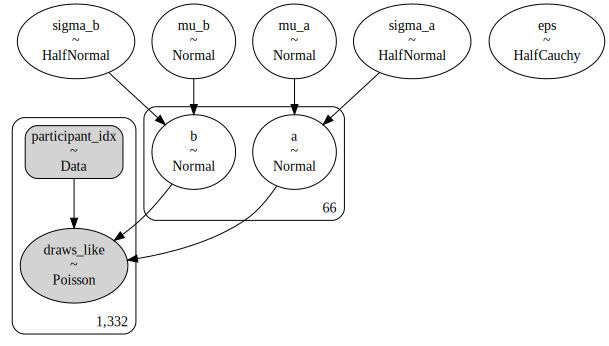

In [8]:
pm.model_to_graphviz(hr_bt)

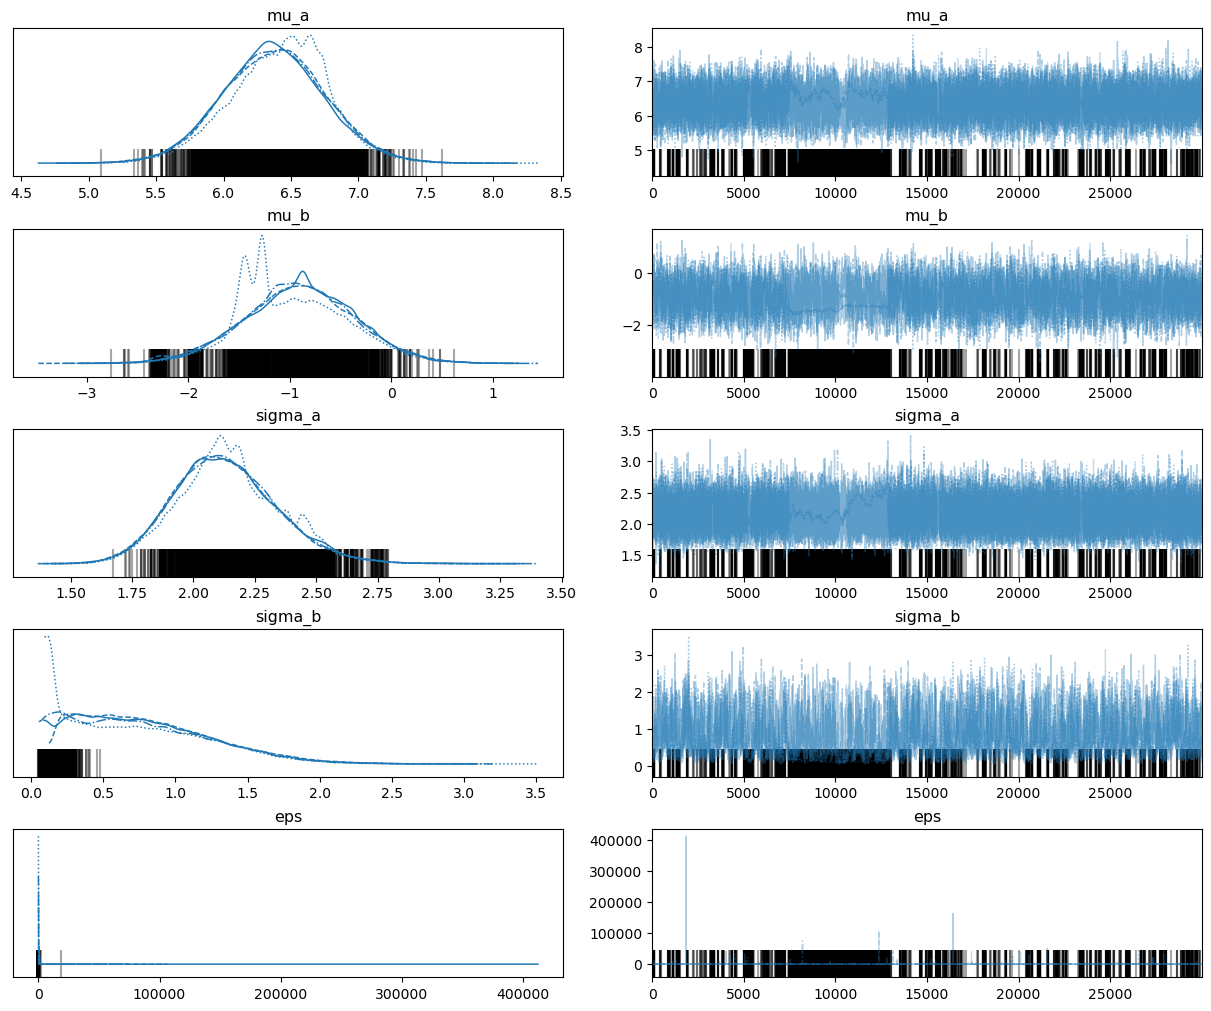

In [14]:
az.plot_trace(hr_bt_trace, var_names=["mu_a", "mu_b", "sigma_a", "sigma_b", "eps"]);


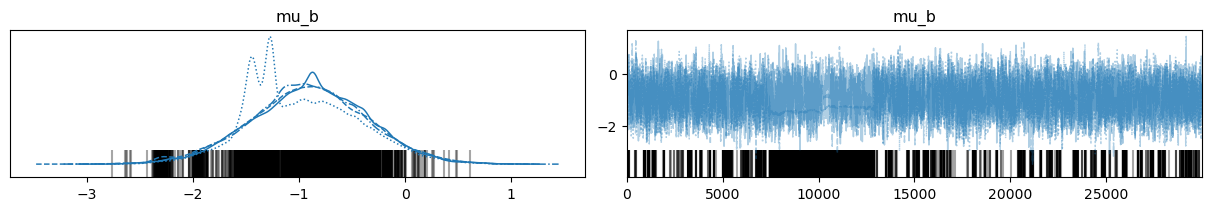

In [15]:
az.plot_trace(hr_bt_trace, var_names=["mu_b"]);


ValueError: not enough values to unpack (expected 2, got 1)

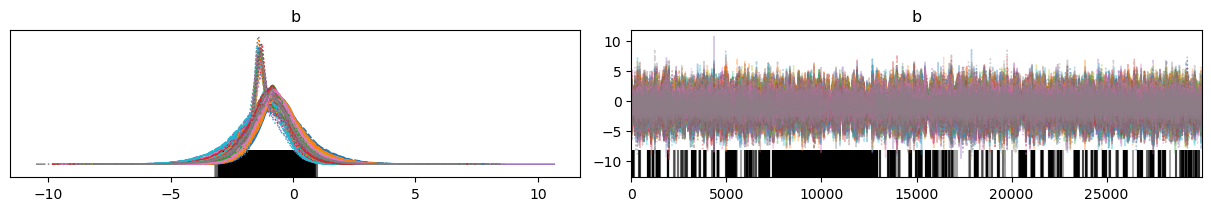

In [16]:
fig, b_trace_BT=az.plot_trace(hr_bt_trace, var_names=["b"], coords={"participant": participant});
b_trace_BT.save("b_trace_BT.jpg")

In [17]:
stat_tms_reg=pm.summary(hr_bt_trace)
stat_tms_reg

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,6.383,0.376,5.658,7.073,0.006,0.004,3847.0,17423.0,1.00
mu_b,-0.929,0.547,-1.955,0.106,0.015,0.011,1255.0,5975.0,1.01
a[0],5.314,0.948,3.479,7.134,0.010,0.007,7764.0,17724.0,1.00
a[1],7.147,0.946,5.268,8.894,0.017,0.012,2594.0,16778.0,1.00
a[2],6.762,0.937,4.910,8.512,0.012,0.008,5084.0,19737.0,1.00
...,...,...,...,...,...,...,...,...,...
b[66],-0.637,0.966,-2.427,1.256,0.026,0.018,1161.0,11410.0,1.01
b[67],-0.930,1.056,-2.921,1.168,0.011,0.008,4944.0,19094.0,1.00
sigma_a,2.135,0.209,1.756,2.535,0.005,0.004,1739.0,5786.0,1.00
sigma_b,0.766,0.476,0.064,1.590,0.028,0.020,155.0,95.0,1.03


In [22]:
b_mu_reg=stat_tms_reg.loc['mu_b']['mean']
b_sigma_reg=stat_tms_reg.loc['mu_b']['sd']

In [23]:

print ("OVL Beta TMS vs O") 
b_tms=NormalDist(mu=b_mu_reg, sigma=b_sigma_reg).overlap(NormalDist(mu=0, sigma=0.5))
print (b_tms)

OVL Beta TMS vs O
0.3743090689822448


In [24]:
dtd_1=trace_groups.get_values(varname="mu", chains=1)
dtd_1=pd.DataFrame(dtd_1)

NameError: name 'trace_groups' is not defined

In [16]:
with hr_bt:
    ppc_reg = pm.sample_posterior_predictive(
        hr_bt_trace, var_names=["a", "b","draws_like"]
    )

<Axes: xlabel='draws_like'>

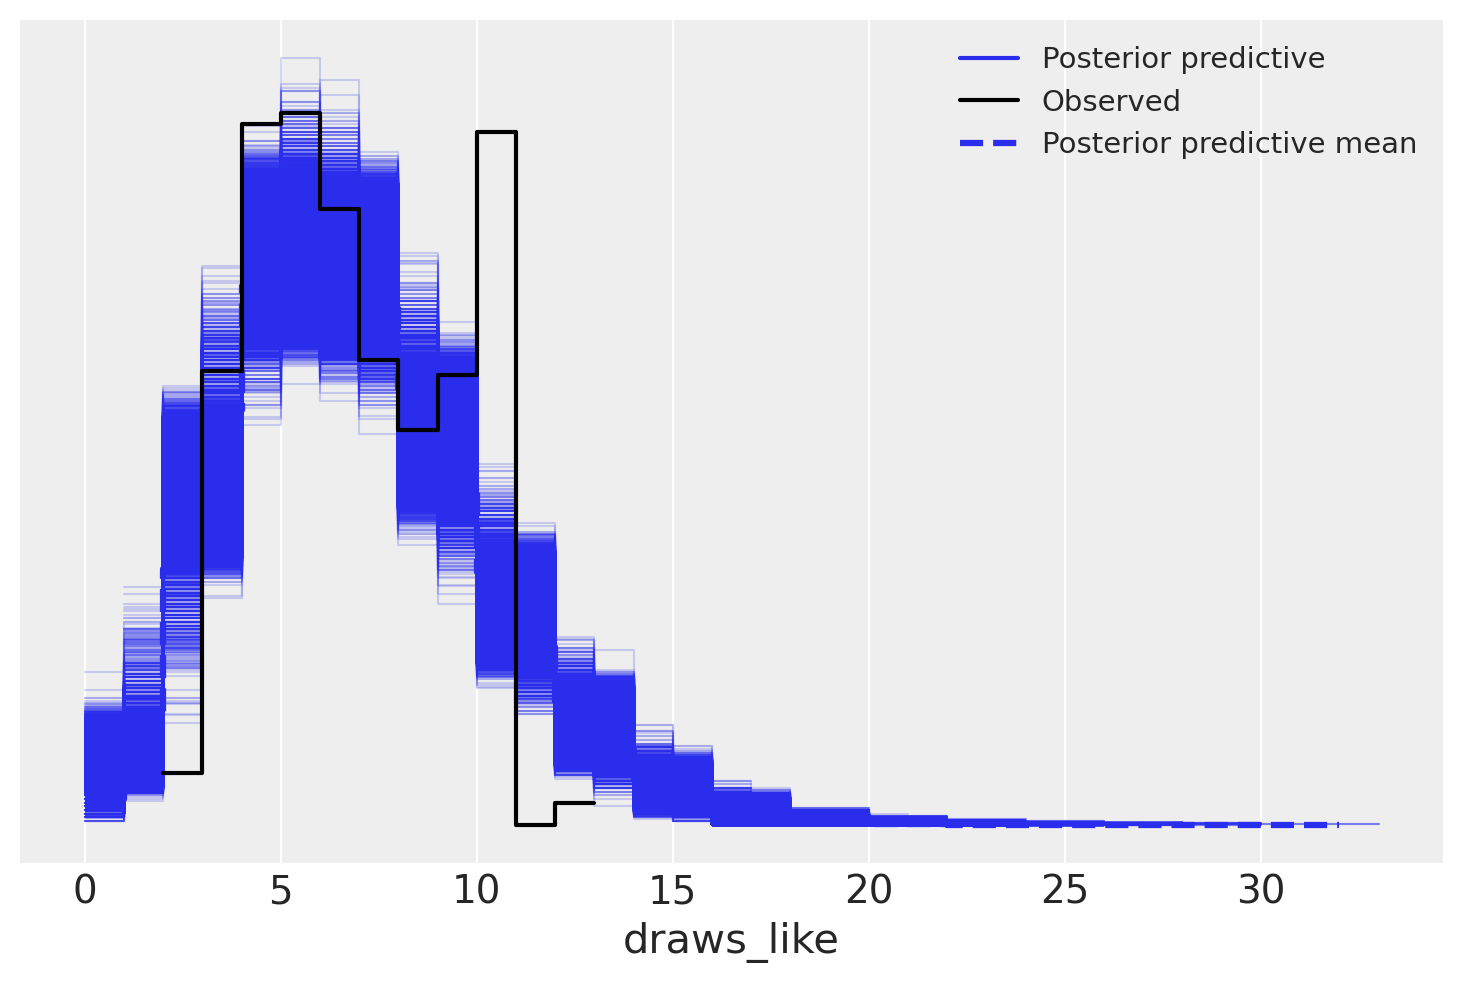

In [15]:
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc_reg, model=hr_bt))